# Exploratory Data Analysis (EDA) — Customer Churn

**Purpose:** Understand the structure, patterns, and distributions in our customer churn data *before* building any models.

**Datasets used (both from `data/02_intermediate/` — already cleaned):**
- `retention_data.csv` — retention cases; contains `Resolution Status` (our churn signal)
- `bob_data.csv` — Book of Business; contains agreement-level details

**Churn definition:**
- *Agreement churn* — `Resolution Status == 'Customer Lost'` for a particular case
- *Full customer churn* — when ALL cases for a customer are 'Customer Lost'

In [9]:
# ── Imports ──────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# WHY: whitegrid gives clean, readable plots for EDA
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

In [10]:
# ── Load both cleaned datasets ──────────────────────────
# WHY: We keep them separate because they represent different
# things — retention cases vs. agreement line-items.
# They share a customer key (Customer Account Number / account_number).

retention = pd.read_csv('../../data/02_intermediate/retention_data.csv')
bob = pd.read_csv('../../data/02_intermediate/bob_data.csv')

print(f"Retention data : {retention.shape[0]:,} rows × {retention.shape[1]} columns")
print(f"BoB data       : {bob.shape[0]:,} rows × {bob.shape[1]} columns")

Retention data : 45,806 rows × 28 columns
BoB data       : 65,883 rows × 26 columns


---
## 1. Dataset Overview

In [11]:
# ── Retention data — column types and sample ────────────
# WHY: We need to know which columns are numerical vs. categorical
# so we can choose the right plots and statistical tests later.

print("RETENTION DATA")
print("=" * 50)
print(retention.dtypes)
print("\nFirst 5 rows:")
retention.head()

RETENTION DATA
Case ID                          str
Case Title                       str
Country                          str
Pull VAN                     float64
New VAN                      float64
VAN                          float64
Number of Contracts          float64
Machines                     float64
Branch                           str
Customer Account Number          str
Customer Name                    str
Agreement End Date               str
Pull Type                        str
Case Type                        str
Risk                             str
Current Status                   str
Resolution Status                str
Number Of Repair Cases       float64
Number of OverdueServices    float64
CompanySize                      str
Customer Tier                    str
Case Origin                      str
Case Creation Date               str
Resolved Time                    str
Registered Time                  str
Resolved Date                    str
Registered Date        

,Case ID,Case Title,Country,Pull VAN,New VAN,VAN,Number of Contracts,Machines,Branch,Customer Account Number,...,Number of OverdueServices,CompanySize,Customer Tier,Case Origin,Case Creation Date,Resolved Time,Registered Time,Resolved Date,Registered Date,Expected Pull Date
0,CAS-38367-V0F4Z3,4.2 Site Closure (Total) - SRF,United Kingdom,0.0,0.0,960.000,1.0,1.0,Southampton,UK02-CGBA121453-L,...,NaN,50-99,Platinum,SR Forms,21-10-2025 15:02,NaN,18:02:09,NaN,21-10-2025,29-Mar-26
1,CAS-38363-V9R1D2,4.2 Site Closure (Total) - SRF,United Kingdom,0.0,0.0,2544.624,1.0,1.0,Southampton,UK02-CGBA121453-L,...,NaN,50-99,Platinum,SR Forms,21-10-2025 15:00,NaN,10:00:00,NaN,21-10-2025,29-Mar-26
2,CAS-38365-P2X2C7,4.2 Site Closure (Total) - SRF,United Kingdom,0.0,0.0,2074.032,1.0,1.0,Southampton,UK02-CGBA121453-L,...,NaN,50-99,Platinum,SR Forms,21-10-2025 15:01,NaN,18:01:03,NaN,21-10-2025,29-Mar-26
3,CAS-24523-T9K0M2,Service Claim,United Kingdom,0.0,0.0,3014.208,1.0,1.0,Dinnington,UK02-CGBA027133-L,...,NaN,500-999,Platinum,Proactive Prevention,15-08-2025 13:44,NaN,16:44:37,NaN,15-08-2025,12-Jul-26
4,CAS-79745-Y5N9Q7,PI2026,United Kingdom,0.0,0.0,1148.400,1.0,1.0,Washington,UK02-SGBA028701-L,...,NaN,100-249,Platinum,Customer Call,18-02-2026 14:40,NaN,16:30:00,NaN,18-02-2026,31-Oct-26


In [12]:
# ── Quick summary statistics for retention numerics ─────
# WHY: Helps us spot outliers, zero-heavy distributions,
# and get a feel for the scale of each numeric column.

retention.describe()

,Pull VAN,New VAN,VAN,Number of Contracts,Machines,Number Of Repair Cases,Number of OverdueServices
count,45806.000000,45806.000000,45689.000000,33857.000000,33857.000000,39084.000000,39084.0
mean,1165.456973,1923.093197,3728.231729,1.343504,3.290398,0.191076,0.0
std,4707.166235,9651.851356,12254.350628,1.387617,6.994159,1.114771,0.0
min,0.000000,-13084.650000,0.000000,1.000000,1.000000,0.000000,0.0
25%,0.000000,0.000000,179.040000,1.000000,1.000000,0.000000,0.0
50%,0.000000,0.000000,1158.120000,1.000000,2.000000,0.000000,0.0
75%,893.518331,264.600000,3262.990576,1.000000,3.000000,0.000000,0.0
max,361773.100000,362747.327700,818018.390000,35.000000,105.000000,33.000000,0.0


In [13]:
# ── BoB data — column types and sample ──────────────────
print("BOB DATA")
print("=" * 50)
print(bob.dtypes)
print("\nFirst 5 rows:")
bob.head()

BOB DATA
account_number              str
company_sizing              str
postal_code                 str
branch                      str
vat_number                  str
agreement_number            str
agreement_start_date        str
agreement_end_date          str
renewal_type                str
agreement_type              str
line_of_business            str
system_status               str
product_bob             float64
fee_bob                 float64
total_bob               float64
is_bob                      str
bpg                         str
msdyn_product_number        str
product_name                str
service_interval        float64
unit_amount             float64
billing_interval        float64
billing_period              str
machine                     str
machine_variant             str
chemistry                   str
dtype: object

First 5 rows:


,account_number,company_sizing,postal_code,branch,vat_number,agreement_number,agreement_start_date,agreement_end_date,renewal_type,agreement_type,...,bpg,msdyn_product_number,product_name,service_interval,unit_amount,billing_interval,billing_period,machine,machine_variant,chemistry
0,UK02-CGBA029544-L,>1000,PE1 5FQ,Elmswell,Unknown,GBC4019041-Machine Services-327311,2025-03-17,2026-03-16,Automatic Renewal,Scheduled Billing,...,17. Ultrasonic,ISK400EAA-001483-001,SK400 EAA + 400L of KLEEN7960S + Waste Rustpro...,1.0,9812.14,1.0,monthly,SK400,AA,KLEEN7960S
1,UK02-CGBA029544-L,>1000,PE1 5FQ,Elmswell,Unknown,GBC4021962-Machine Services-332280,2025-04-14,2028-04-13,Automatic Renewal,Scheduled Billing,...,17. Ultrasonic,ISK600EAA-001356-001,SK600 EAA + 600L of KLEEN7960S + Waste Rustpro...,1.0,8830.64,1.0,monthly,SK600,AA,KLEEN7960S
2,UK02-CGBA029544-L,>1000,PE1 5FQ,Elmswell,Unknown,GBC4021962-Machine Services-332282,2025-04-14,2028-04-13,Automatic Renewal,Scheduled Billing,...,17. Ultrasonic,ISK600EAA-001356-001,SK600 EAA + 600L of KLEEN7960S + Waste Rustpro...,1.0,8830.64,1.0,monthly,SK600,AA,KLEEN7960S
3,UK02-CGBA124601-L,20-49,BT71 7ET,Lisburn,GB714768220,GBC4000950-Auto waste,2022-06-24,2026-06-23,Automatic Renewal,Scheduled Billing,...,40. Oil Filters,K0000-040259-000,Waste Paint Sludge Collection - 205,0.0,7686.88,1.0,monthly,NaN,NaN,NaN
4,UK02-CGBA034502-L,50-99,BT41 3UF,Lisburn,Unknown,GBC3028394-Chemistry,2024-11-04,2025-11-03,Automatic Renewal,Scheduled Billing,...,30. Allied Products,C0000-000468-001,Delivery of Std Thinners - 205Ltrs (6),1.0,6933.91,1.0,monthly,NaN,NaN,NaN


In [14]:
# ── Quick summary statistics for BoB numerics ───────────
bob.describe()

,product_bob,fee_bob,total_bob,service_interval,unit_amount,billing_interval
count,65883.000000,65883.000000,65883.000000,62785.000000,64152.000000,60805.000000
mean,2524.457354,69.901917,2594.359271,14.186541,231.335357,1.067198
std,3988.967332,178.315267,4023.538485,13.468743,396.203948,0.869876
min,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,522.480000,0.000000,557.185000,5.000000,46.300000,1.000000
50%,1439.400000,0.000000,1500.000000,9.000000,126.470000,1.000000
75%,2947.140000,96.725000,3050.160000,14.000000,268.415000,1.000000
max,117745.680000,24129.960000,118700.400000,53.000000,9812.140000,52.000000


---
## 2. Target Variable Analysis

The target comes from the **retention** data's `Resolution Status` column.  
- `'Customer Lost'` → the agreement was lost (agreement-level churn).  
- If ALL of a customer's cases are `'Customer Lost'` → full customer churn.

Resolution Status — value counts:
Resolution Status
Customer Saved               21459
Customer Lost                14486
Converted to Cancellation     5818
OPEN - In Progress            4015
OPEN - Pull Confirmed           24
Unknown                          4
Name: count, dtype: int64


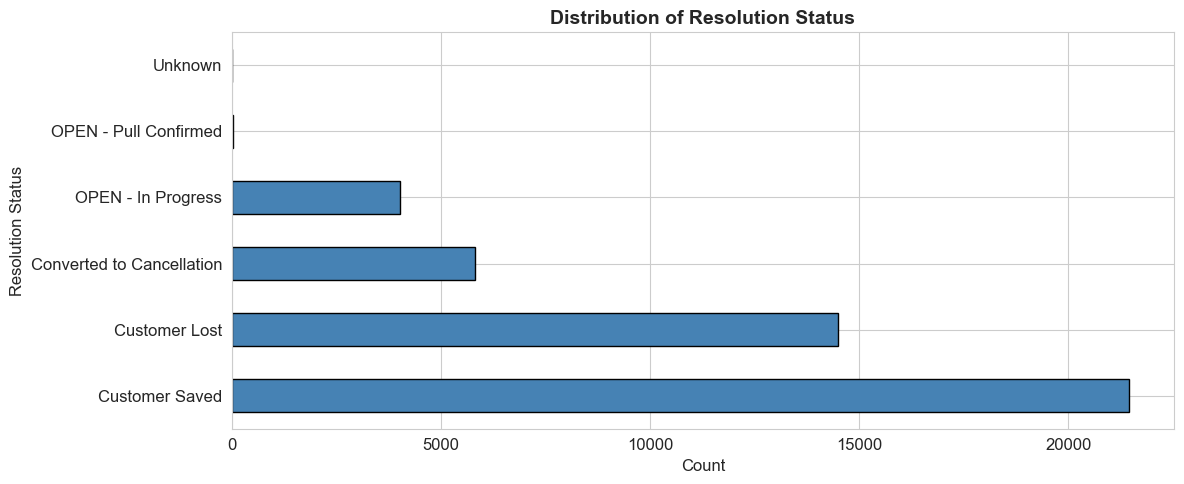

In [15]:
# ── 2a. Resolution Status distribution ──────────────────
# WHY: Before creating binary labels we need to see ALL
# possible values and how frequent each is.

print("Resolution Status — value counts:")
print(retention['Resolution Status'].value_counts())

fig, ax = plt.subplots(figsize=(12, 5))
retention['Resolution Status'].value_counts().plot(
    kind='barh', color='steelblue', edgecolor='black', ax=ax
)
ax.set_title('Distribution of Resolution Status', fontsize=14, fontweight='bold')
ax.set_xlabel('Count')
plt.tight_layout()
plt.show()

In [16]:
# ── 2b. Create agreement-level churn flag ────────────────
# WHY: We need a binary 0/1 target for modelling.
# 'Customer Lost' in Resolution Status means churn for that agreement.

retention['agreement_churn'] = (
    retention['Resolution Status'] == 'Customer Lost'
).astype(int)

print("Agreement-Level Churn Distribution:")
print(retention['agreement_churn'].value_counts())
print(f"\nChurn rate: {retention['agreement_churn'].mean():.2%}")

Agreement-Level Churn Distribution:
agreement_churn
0    31320
1    14486
Name: count, dtype: int64

Churn rate: 31.62%


In [17]:
# ── 2c. Derive full customer churn ───────────────────────
# WHY: A customer is fully churned only when ALL their
# retention cases ended in 'Customer Lost'.
# This is a stricter, more impactful metric.

customer_summary = retention.groupby('Customer Account Number').agg(
    total_cases   = ('agreement_churn', 'count'),
    churned_cases = ('agreement_churn', 'sum')
).reset_index()

# Ratio of churned cases to total cases per customer
customer_summary['churn_ratio'] = (
    customer_summary['churned_cases'] / customer_summary['total_cases']
)

# Full churn = 100 % of cases are 'Customer Lost'
customer_summary['customer_churn'] = (
    customer_summary['churn_ratio'] == 1.0
).astype(int)

print("Full Customer Churn Distribution:")
print(customer_summary['customer_churn'].value_counts())
print(f"Full customer churn rate: {customer_summary['customer_churn'].mean():.2%}")

Full Customer Churn Distribution:
customer_churn
0    16644
1     4882
Name: count, dtype: int64
Full customer churn rate: 22.68%


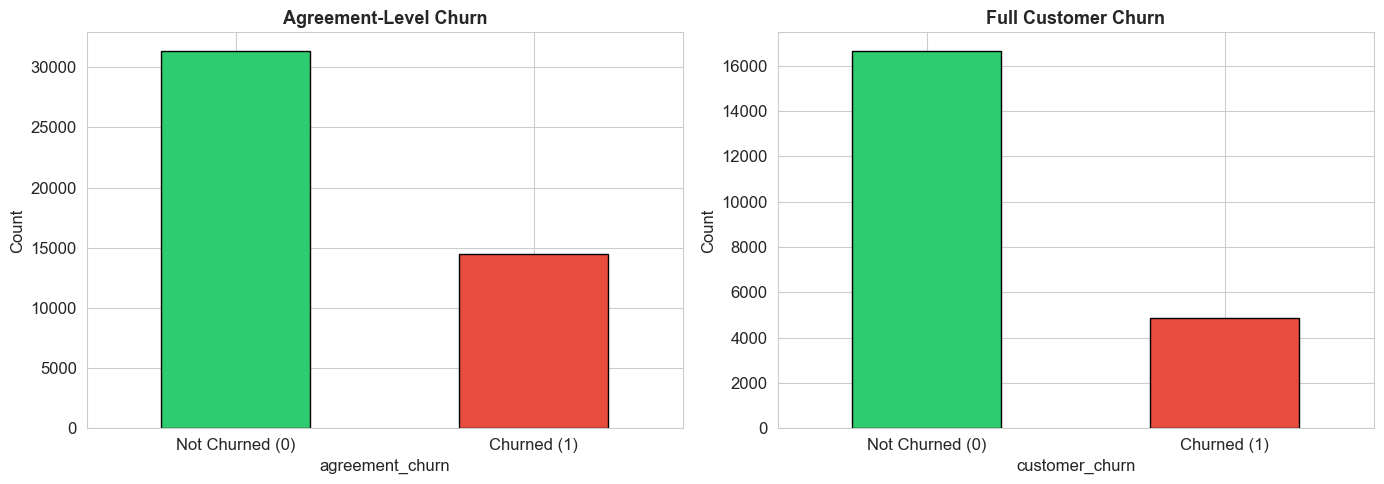

In [18]:
# ── 2d. Visualise both churn distributions side by side ──
# WHY: Seeing class balance is critical — if the target is
# highly imbalanced we'll need to handle that in modelling.

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ['#2ecc71', '#e74c3c']  # green = no churn, red = churned

# Agreement-level
retention['agreement_churn'].value_counts().sort_index().plot(
    kind='bar', color=colors, edgecolor='black', ax=axes[0]
)
axes[0].set_title('Agreement-Level Churn', fontsize=13, fontweight='bold')
axes[0].set_xticklabels(['Not Churned (0)', 'Churned (1)'], rotation=0)
axes[0].set_ylabel('Count')

# Customer-level
customer_summary['customer_churn'].value_counts().sort_index().plot(
    kind='bar', color=colors, edgecolor='black', ax=axes[1]
)
axes[1].set_title('Full Customer Churn', fontsize=13, fontweight='bold')
axes[1].set_xticklabels(['Not Churned (0)', 'Churned (1)'], rotation=0)
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

---
## 3. Missing Value Analysis

We visualise missing data to decide which columns are usable  
and which may need imputation or dropping in feature engineering.

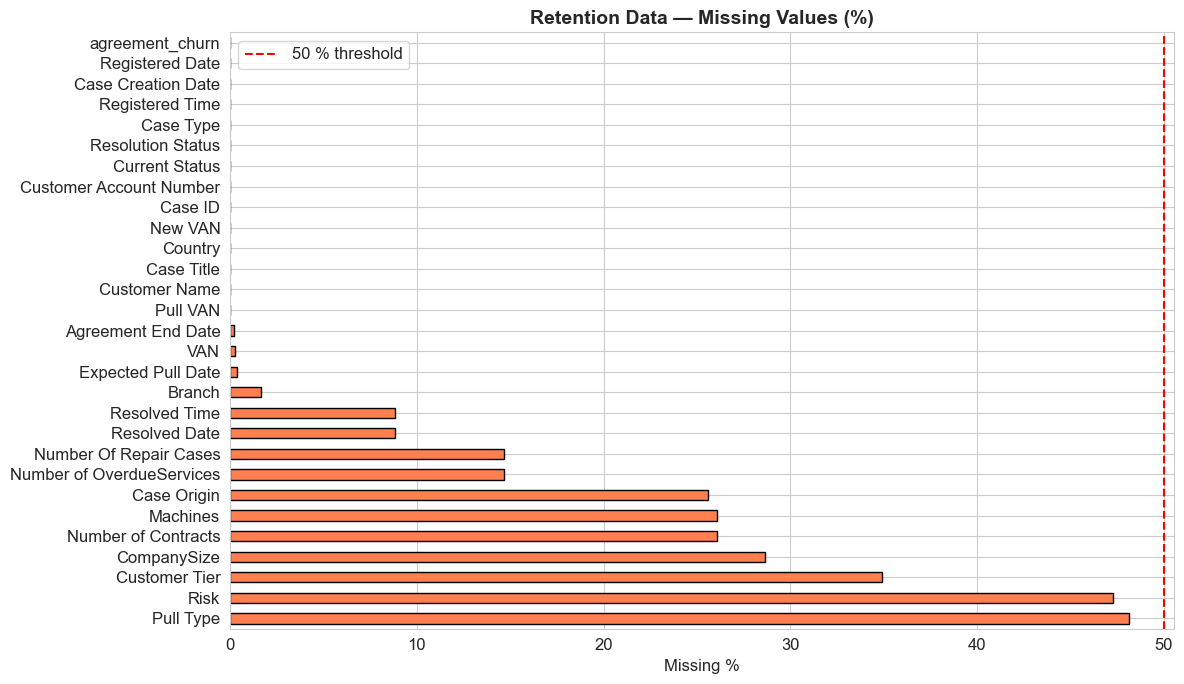


Missing % per column:
Pull Type                    48.14
Risk                         47.27
Customer Tier                34.91
CompanySize                  28.66
Number of Contracts          26.09
Machines                     26.09
Case Origin                  25.59
Number of OverdueServices    14.67
Number Of Repair Cases       14.67
Resolved Date                 8.82
Resolved Time                 8.82
Branch                        1.67
Expected Pull Date            0.35
VAN                           0.26
Agreement End Date            0.21
Pull VAN                      0.00
Customer Name                 0.00
Case Title                    0.00
Country                       0.00
New VAN                       0.00
Case ID                       0.00
Customer Account Number       0.00
Current Status                0.00
Resolution Status             0.00
Case Type                     0.00
Registered Time               0.00
Case Creation Date            0.00
Registered Date               0.

In [19]:
# ── 3a. Missing values — Retention data ──────────────────
# WHY: Columns with very high missingness (>50 %) may not
# be worth keeping; low-missingness columns can be imputed.

ret_missing = (retention.isnull().mean() * 100).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 7))
ret_missing.plot(kind='barh', color='coral', edgecolor='black', ax=ax)
ax.set_title('Retention Data — Missing Values (%)', fontsize=14, fontweight='bold')
ax.set_xlabel('Missing %')
ax.axvline(x=50, color='red', linestyle='--', label='50 % threshold')
ax.legend()
plt.tight_layout()
plt.show()

print("\nMissing % per column:")
print(ret_missing.round(2))

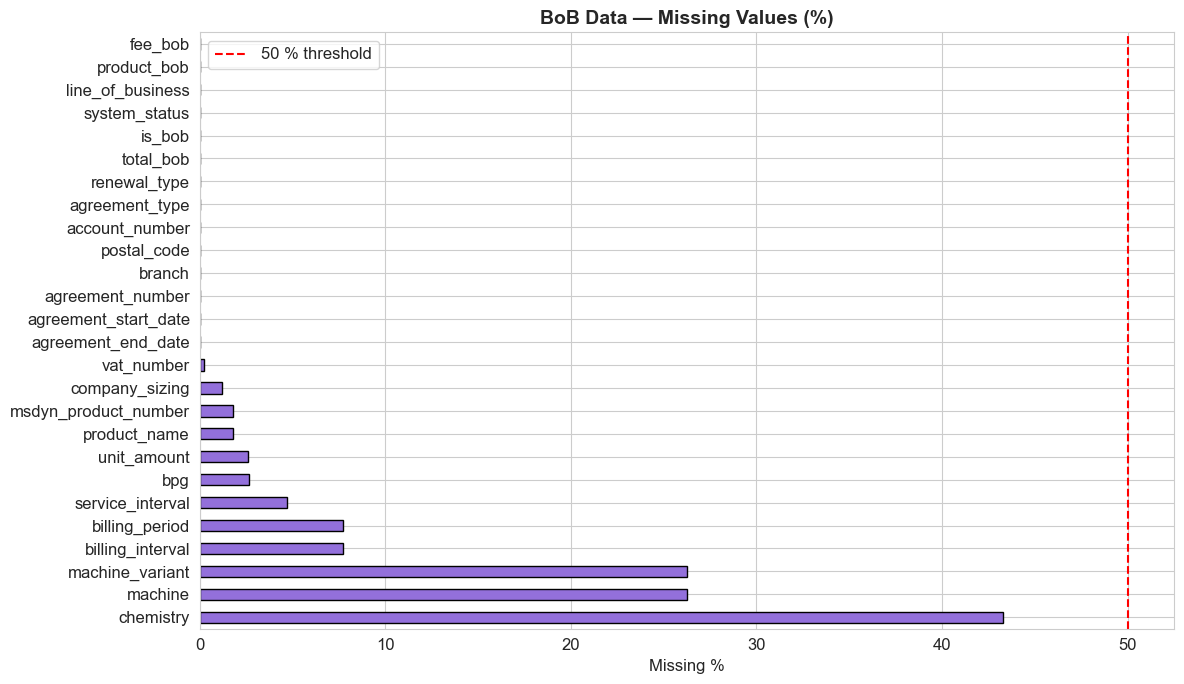


Missing % per column:
chemistry               43.29
machine                 26.28
machine_variant         26.27
billing_interval         7.71
billing_period           7.71
service_interval         4.70
bpg                      2.65
unit_amount              2.63
product_name             1.78
msdyn_product_number     1.78
company_sizing           1.22
vat_number               0.22
agreement_end_date       0.00
agreement_start_date     0.00
agreement_number         0.00
branch                   0.00
postal_code              0.00
account_number           0.00
agreement_type           0.00
renewal_type             0.00
total_bob                0.00
is_bob                   0.00
system_status            0.00
line_of_business         0.00
product_bob              0.00
fee_bob                  0.00
dtype: float64


In [20]:
# ── 3b. Missing values — BoB data ────────────────────────
bob_missing = (bob.isnull().mean() * 100).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 7))
bob_missing.plot(kind='barh', color='mediumpurple', edgecolor='black', ax=ax)
ax.set_title('BoB Data — Missing Values (%)', fontsize=14, fontweight='bold')
ax.set_xlabel('Missing %')
ax.axvline(x=50, color='red', linestyle='--', label='50 % threshold')
ax.legend()
plt.tight_layout()
plt.show()

print("\nMissing % per column:")
print(bob_missing.round(2))

---
## 4. Univariate Analysis — Numerical Features

Look at distributions of key numeric columns to spot skewness,  
outliers, and zero-heavy patterns.

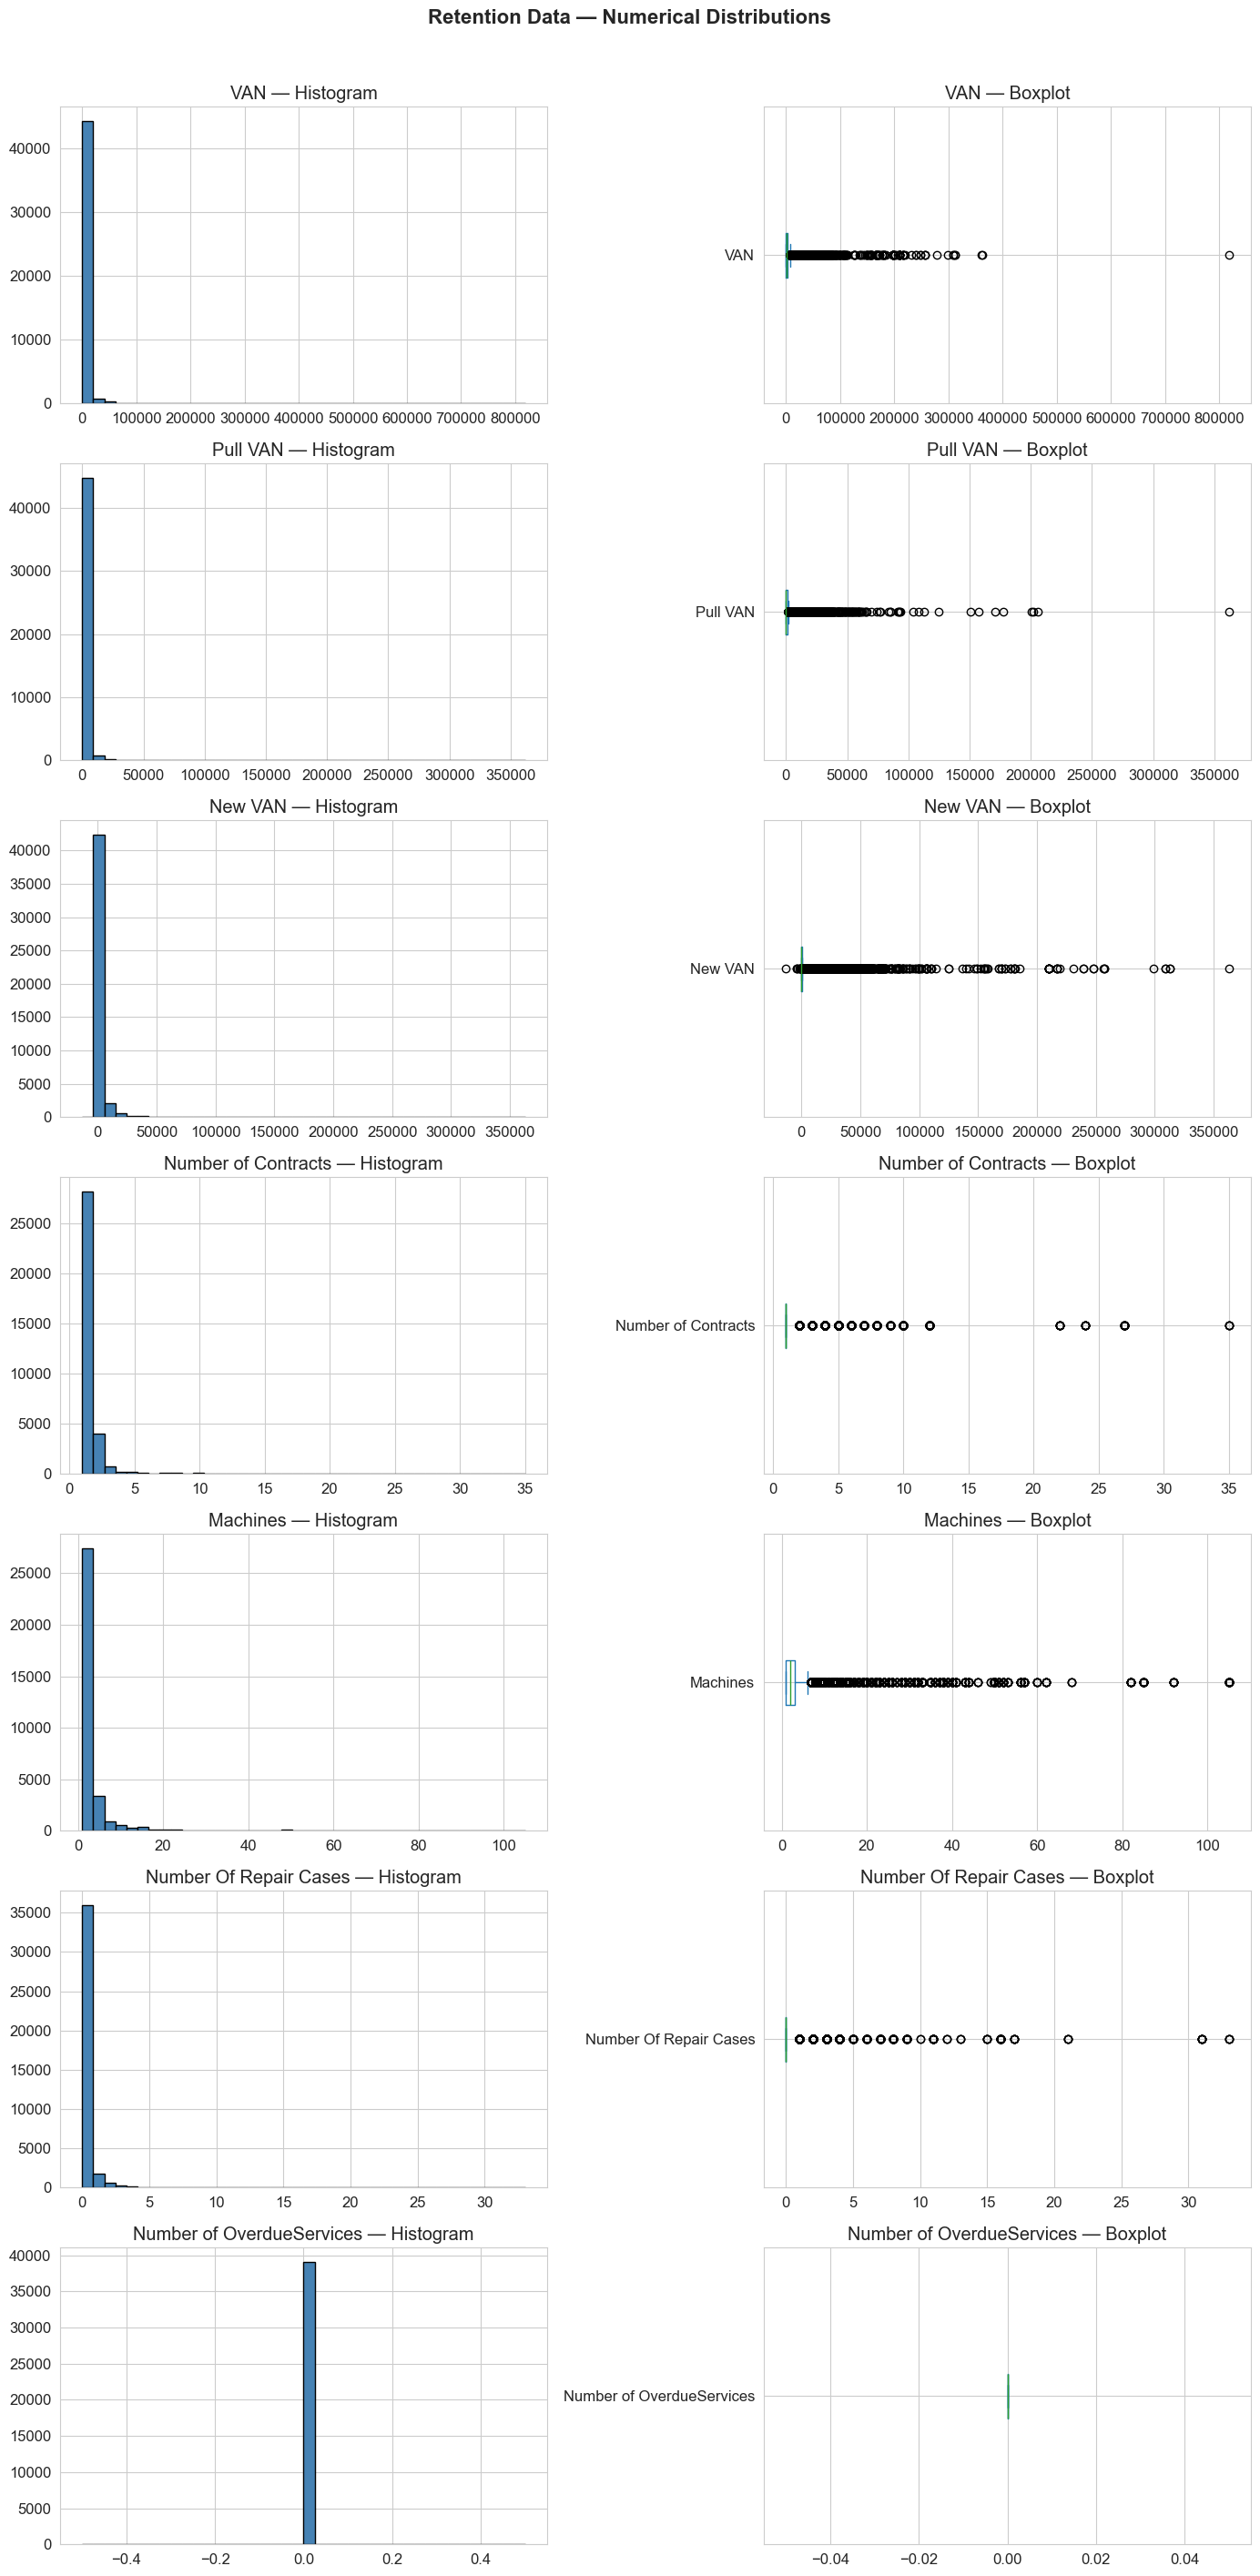

In [21]:
# ── 4a. Retention — numeric distributions ────────────────
# WHY: Skewed or zero-heavy columns may need transformation;
# outliers could affect model performance.

ret_numeric_cols = ['VAN', 'Pull VAN', 'New VAN',
                    'Number of Contracts', 'Machines',
                    'Number Of Repair Cases', 'Number of OverdueServices']

# Only keep columns that actually exist in the data
ret_numeric_cols = [c for c in ret_numeric_cols if c in retention.columns]

fig, axes = plt.subplots(len(ret_numeric_cols), 2,
                         figsize=(14, 4 * len(ret_numeric_cols)))

for i, col in enumerate(ret_numeric_cols):
    # Histogram
    retention[col].dropna().hist(bins=40, color='steelblue',
                                 edgecolor='black', ax=axes[i, 0])
    axes[i, 0].set_title(f'{col} — Histogram')

    # Boxplot
    retention[col].dropna().plot.box(ax=axes[i, 1], vert=False)
    axes[i, 1].set_title(f'{col} — Boxplot')

plt.suptitle('Retention Data — Numerical Distributions',
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

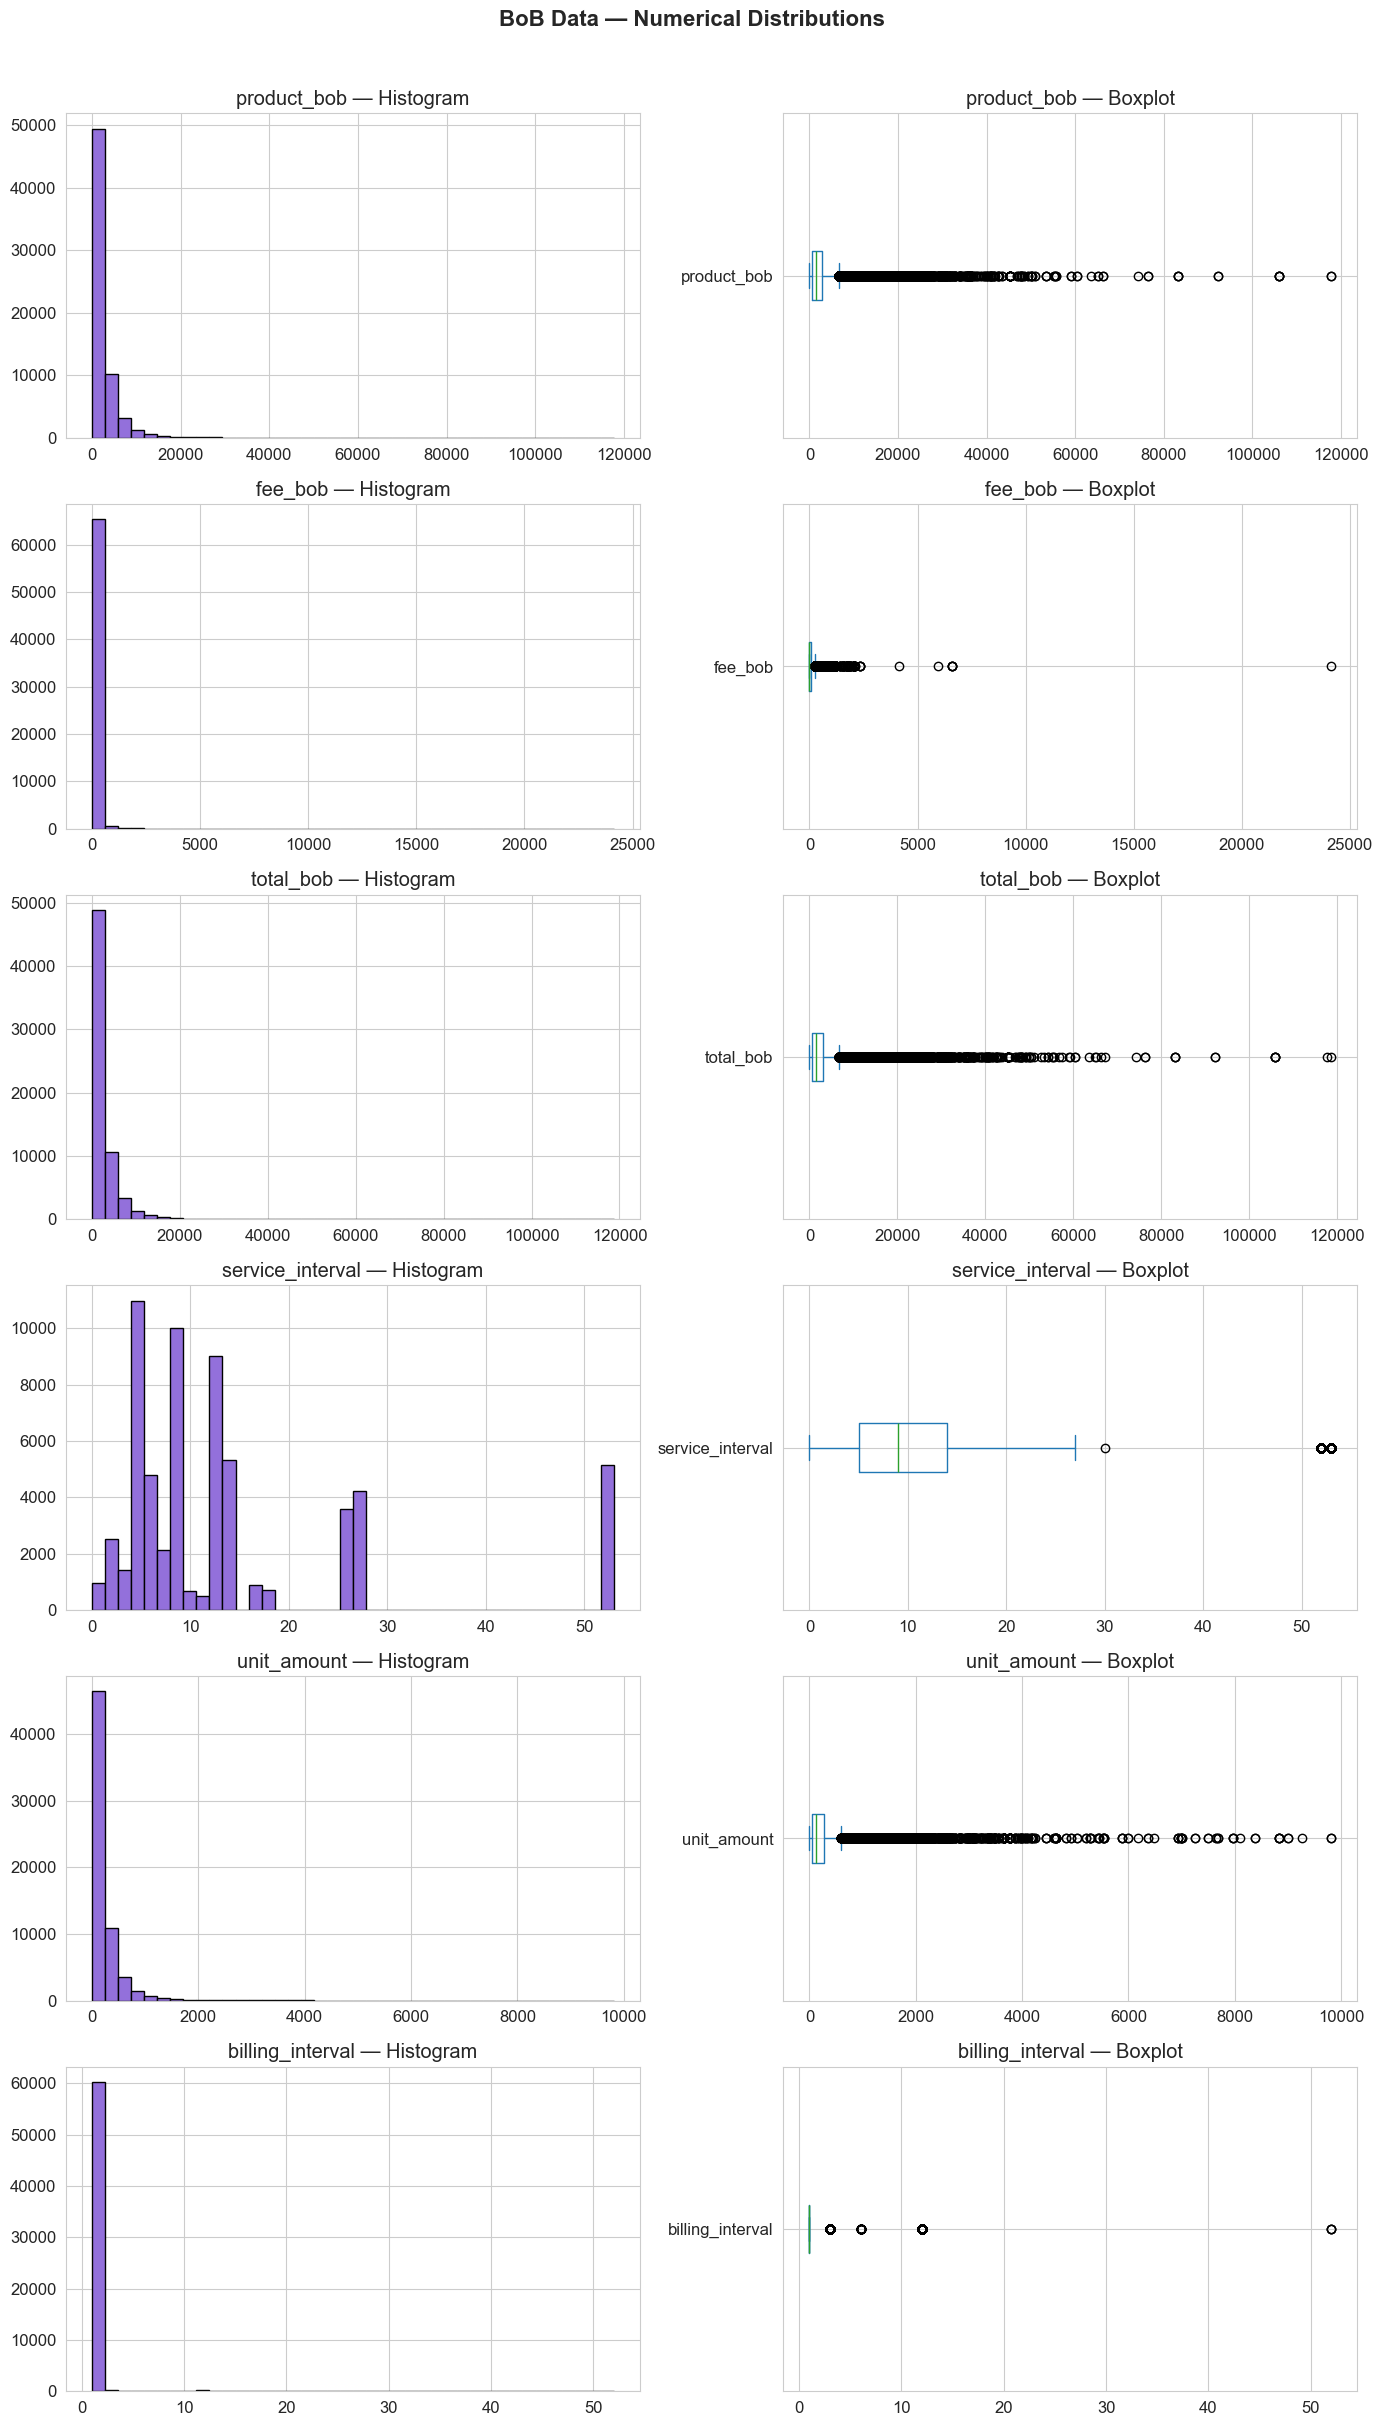

In [22]:
# ── 4b. BoB — numeric distributions ──────────────────────
bob_numeric_cols = ['product_bob', 'fee_bob', 'total_bob',
                    'service_interval', 'unit_amount', 'billing_interval']

bob_numeric_cols = [c for c in bob_numeric_cols if c in bob.columns]

fig, axes = plt.subplots(len(bob_numeric_cols), 2,
                         figsize=(14, 4 * len(bob_numeric_cols)))

for i, col in enumerate(bob_numeric_cols):
    bob[col].dropna().hist(bins=40, color='mediumpurple',
                            edgecolor='black', ax=axes[i, 0])
    axes[i, 0].set_title(f'{col} — Histogram')

    bob[col].dropna().plot.box(ax=axes[i, 1], vert=False)
    axes[i, 1].set_title(f'{col} — Boxplot')

plt.suptitle('BoB Data — Numerical Distributions',
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

---
## 5. Univariate Analysis — Categorical Features

Count plots for the most important categorical columns to see  
category frequencies and whether any category dominates.

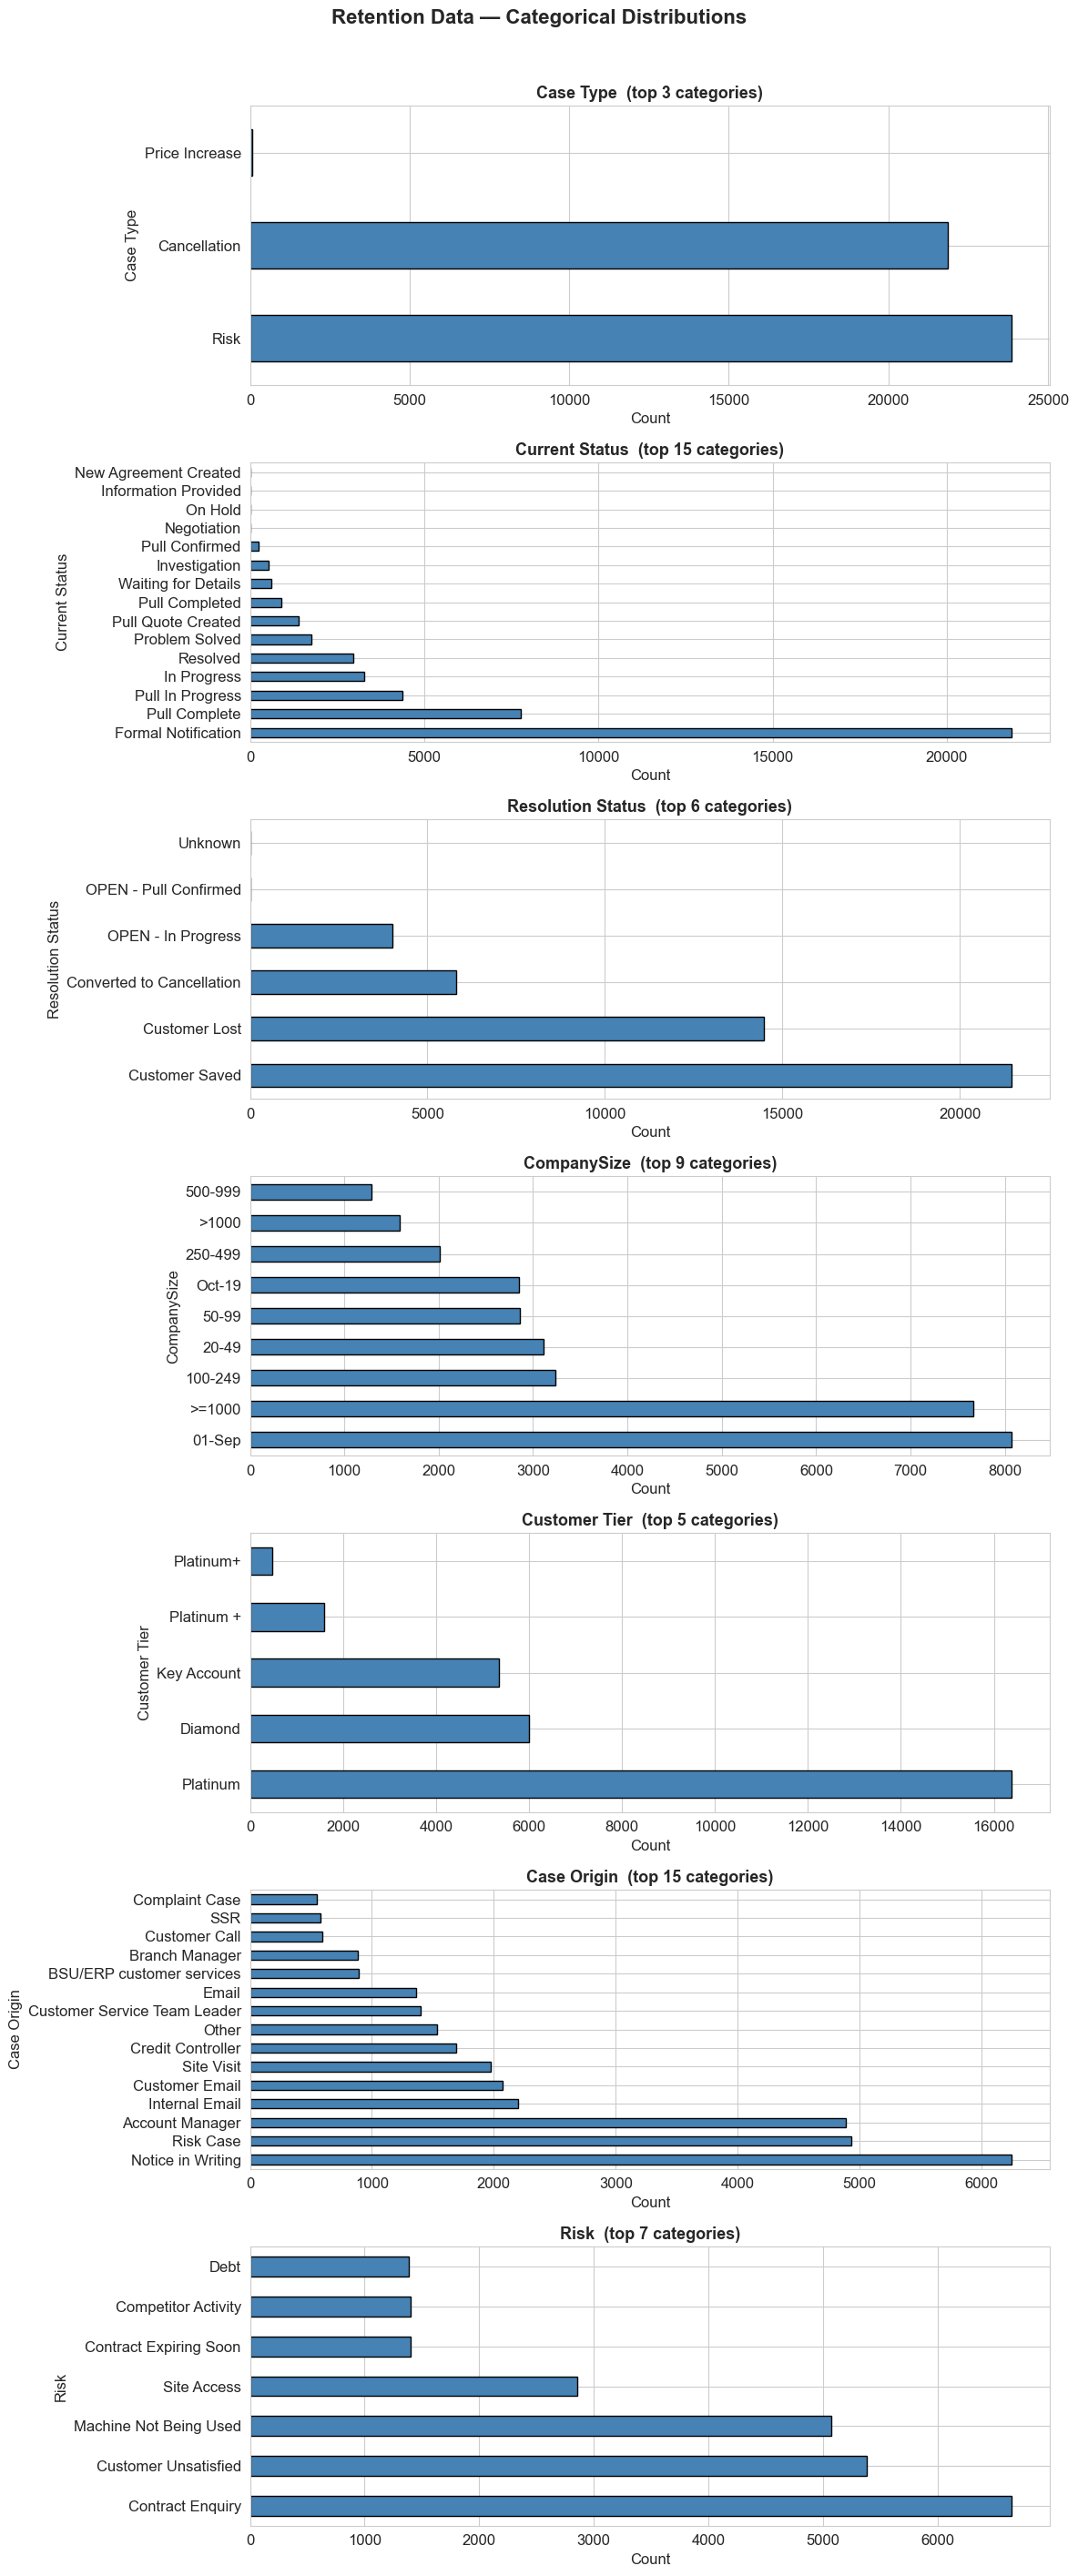

In [23]:
# ── 5a. Retention — key categorical columns ──────────────
# WHY: Dominant categories with >90 % share have little
# predictive value; rare categories may need grouping.

ret_cat_cols = ['Case Type', 'Current Status', 'Resolution Status',
                'CompanySize', 'Customer Tier', 'Case Origin', 'Risk']

ret_cat_cols = [c for c in ret_cat_cols if c in retention.columns]

fig, axes = plt.subplots(len(ret_cat_cols), 1,
                         figsize=(12, 4 * len(ret_cat_cols)))

for i, col in enumerate(ret_cat_cols):
    # Show top 15 categories to keep readable
    top_vals = retention[col].value_counts().head(15)
    top_vals.plot(kind='barh', color='steelblue',
                  edgecolor='black', ax=axes[i])
    axes[i].set_title(f'{col}  (top {min(15, len(top_vals))} categories)',
                      fontsize=13, fontweight='bold')
    axes[i].set_xlabel('Count')

plt.suptitle('Retention Data — Categorical Distributions',
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

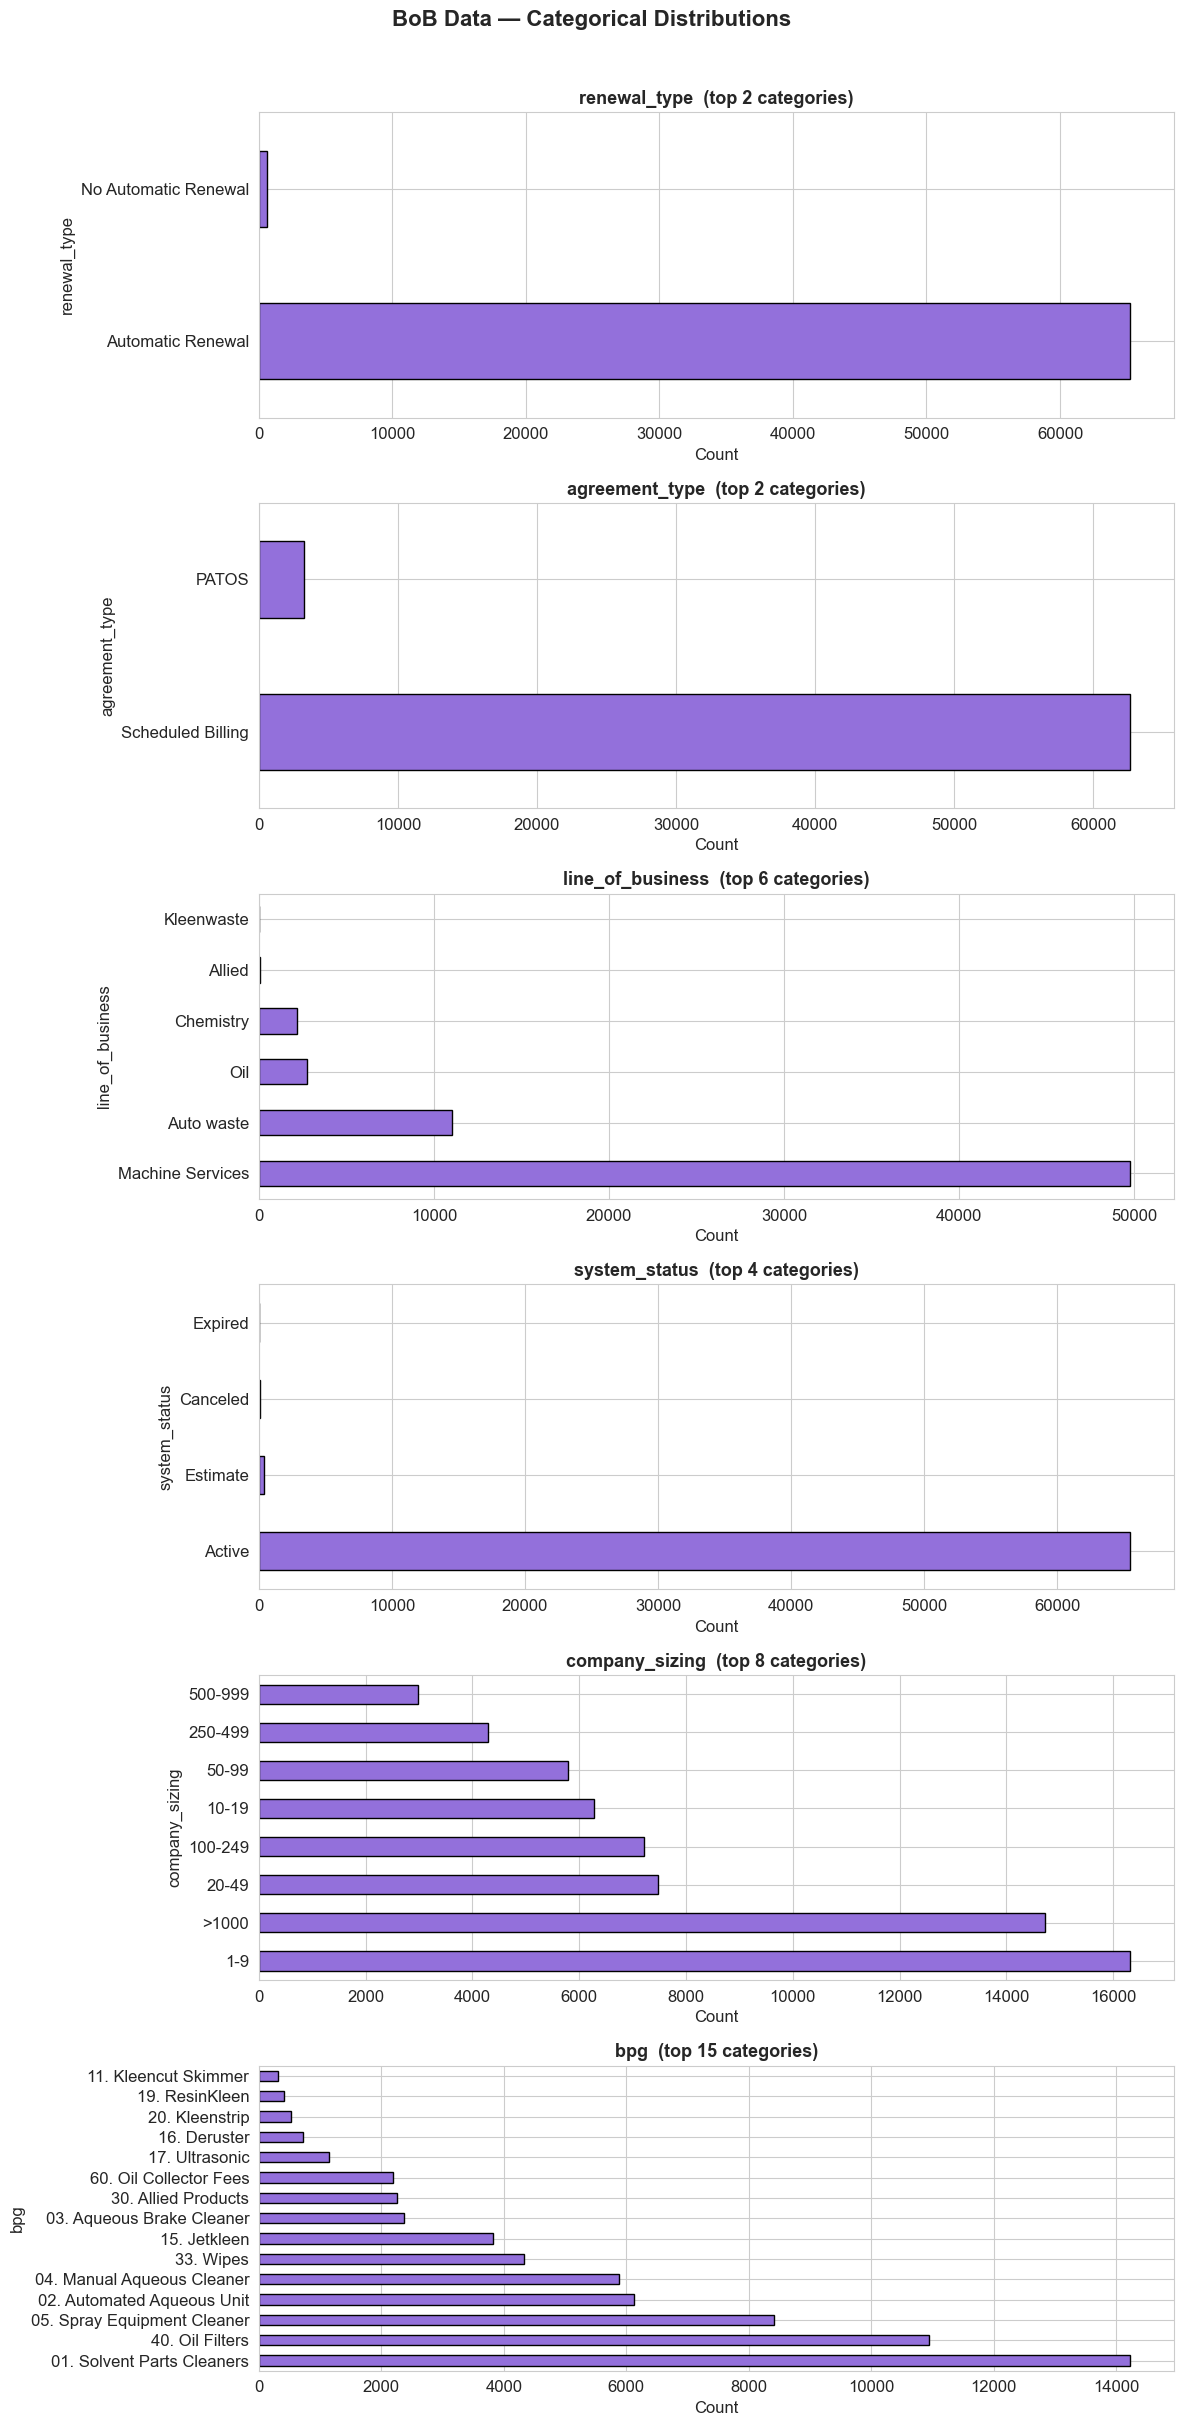

In [24]:
# ── 5b. BoB — key categorical columns ────────────────────
bob_cat_cols = ['renewal_type', 'agreement_type', 'line_of_business',
                'system_status', 'company_sizing', 'bpg']

bob_cat_cols = [c for c in bob_cat_cols if c in bob.columns]

fig, axes = plt.subplots(len(bob_cat_cols), 1,
                         figsize=(12, 4 * len(bob_cat_cols)))

for i, col in enumerate(bob_cat_cols):
    top_vals = bob[col].value_counts().head(15)
    top_vals.plot(kind='barh', color='mediumpurple',
                  edgecolor='black', ax=axes[i])
    axes[i].set_title(f'{col}  (top {min(15, len(top_vals))} categories)',
                      fontsize=13, fontweight='bold')
    axes[i].set_xlabel('Count')

plt.suptitle('BoB Data — Categorical Distributions',
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

---
## 6. Bivariate Analysis — Features vs Churn

**WHY:** The most important part of EDA — do features actually  
differ between churned and non-churned groups?

We compare:
1. Churn rate across categories (bar charts)
2. Numerical feature distributions split by churn (boxplots)

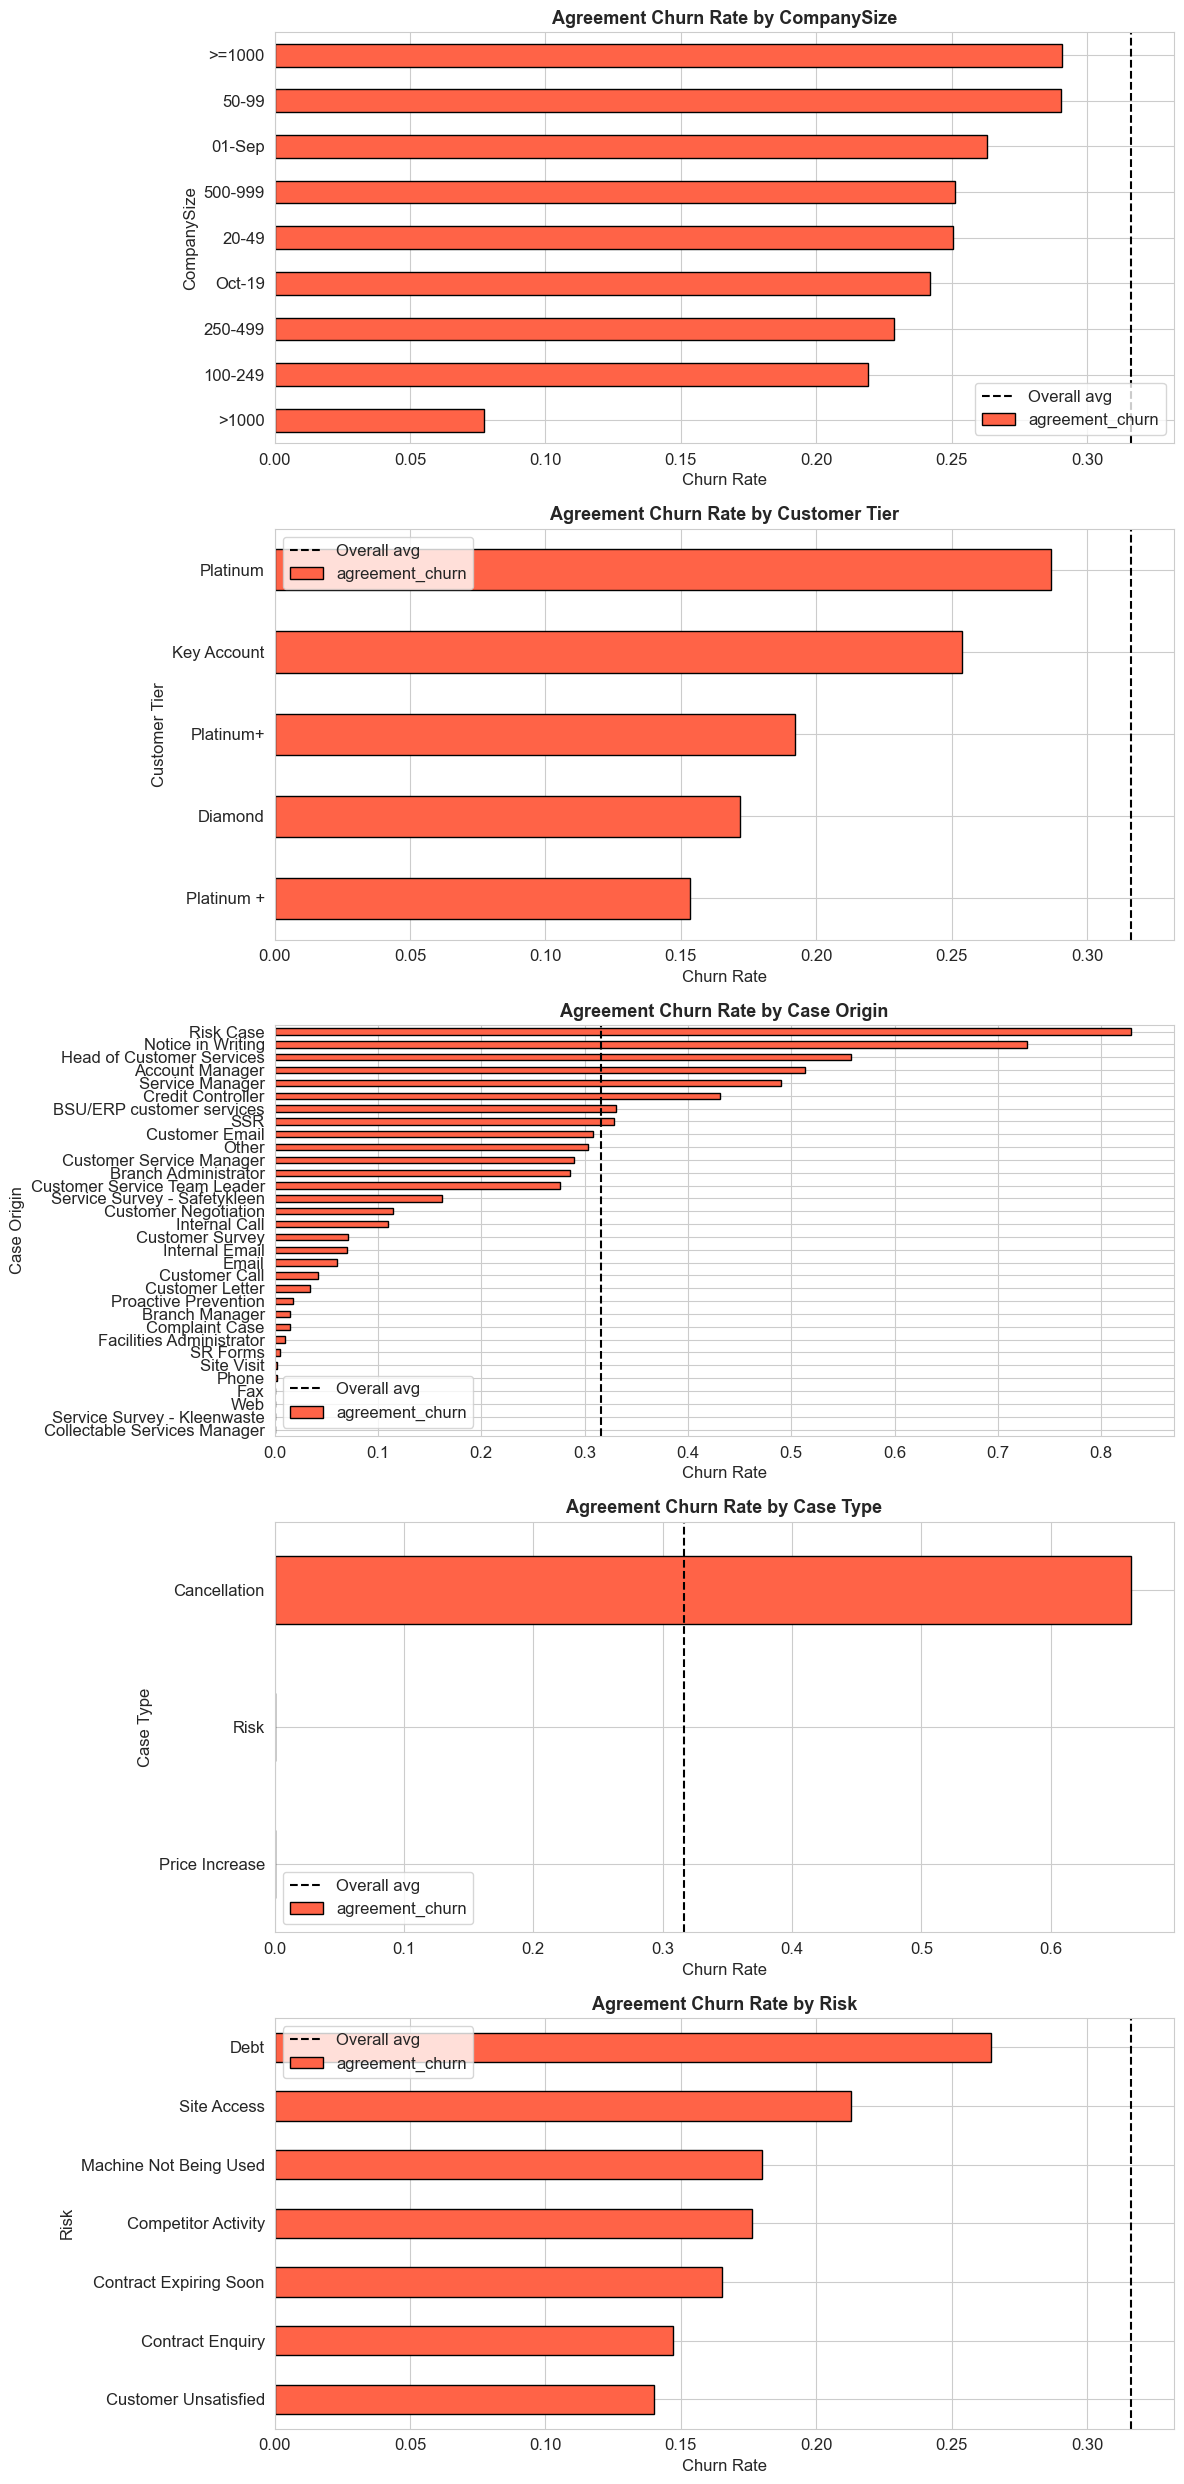

In [25]:
# ── 6a. Churn rate by categorical features ───────────────
# WHY: If churn rate differs a lot between categories,
# that feature is likely a good predictor.

bivar_cat_cols = ['CompanySize', 'Customer Tier', 'Case Origin',
                  'Case Type', 'Risk']
bivar_cat_cols = [c for c in bivar_cat_cols if c in retention.columns]

fig, axes = plt.subplots(len(bivar_cat_cols), 1,
                         figsize=(12, 5 * len(bivar_cat_cols)))

for i, col in enumerate(bivar_cat_cols):
    # Calculate churn rate per category
    churn_rate = retention.groupby(col)['agreement_churn'].mean().sort_values()

    churn_rate.plot(kind='barh', color='tomato',
                    edgecolor='black', ax=axes[i])
    axes[i].set_title(f'Agreement Churn Rate by {col}',
                      fontsize=13, fontweight='bold')
    axes[i].set_xlabel('Churn Rate')
    axes[i].axvline(x=retention['agreement_churn'].mean(),
                    color='black', linestyle='--', label='Overall avg')
    axes[i].legend()

plt.tight_layout()
plt.show()

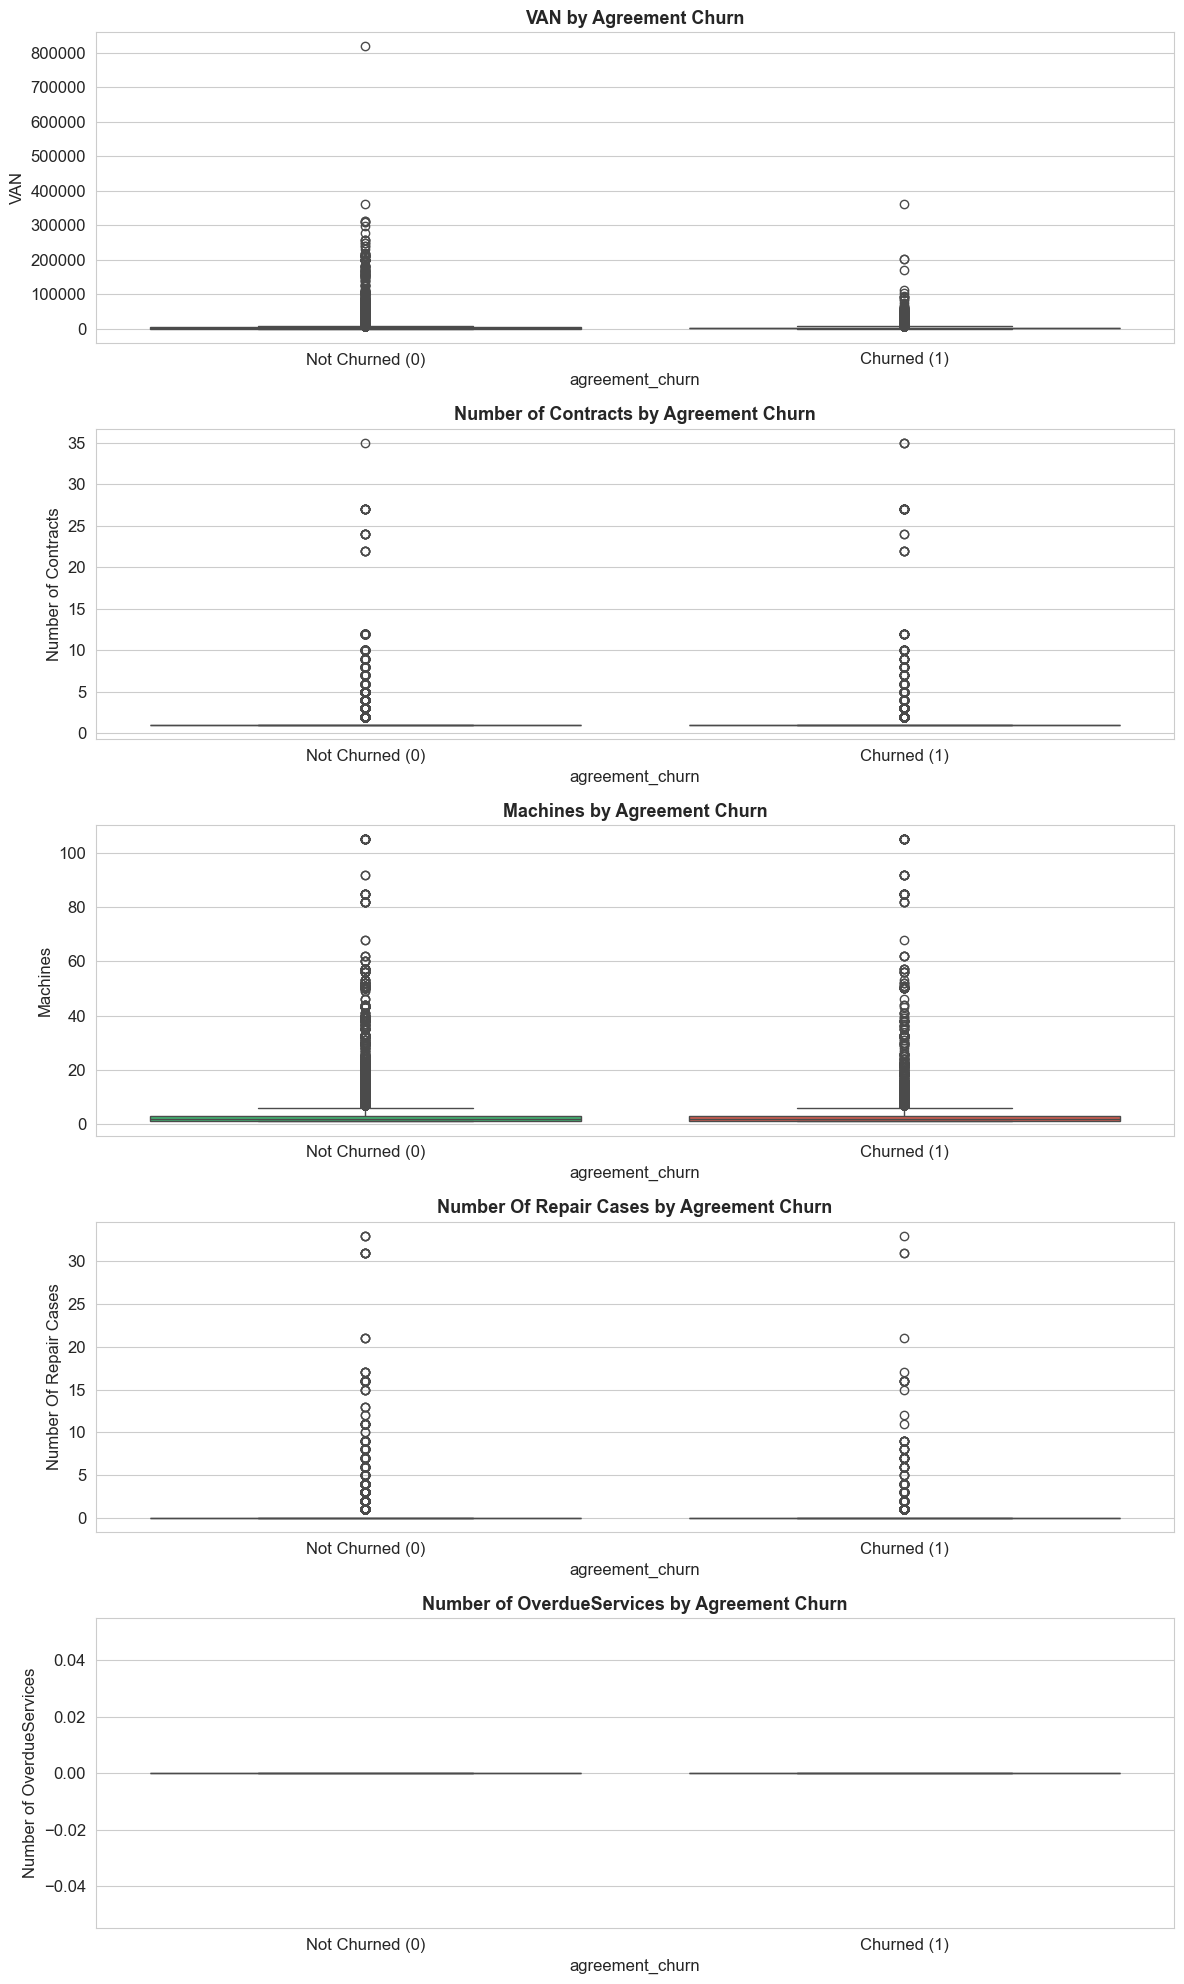

In [26]:
# ── 6b. Numerical features — churned vs not churned ──────
# WHY: If the distributions clearly separate, the feature
# will help the model distinguish churned customers.

bivar_num_cols = ['VAN', 'Number of Contracts', 'Machines',
                  'Number Of Repair Cases', 'Number of OverdueServices']
bivar_num_cols = [c for c in bivar_num_cols if c in retention.columns]

fig, axes = plt.subplots(len(bivar_num_cols), 1,
                         figsize=(12, 4 * len(bivar_num_cols)))

for i, col in enumerate(bivar_num_cols):
    sns.boxplot(data=retention, x='agreement_churn', y=col,
                palette=['#2ecc71', '#e74c3c'], ax=axes[i])
    axes[i].set_title(f'{col} by Agreement Churn',
                      fontsize=13, fontweight='bold')
    axes[i].set_xticklabels(['Not Churned (0)', 'Churned (1)'])

plt.tight_layout()
plt.show()

---
## 7. Correlation Heatmap

**WHY:** Highly correlated features are redundant — we'll need  
to drop one of each pair later. Also shows which features  
correlate with the target.

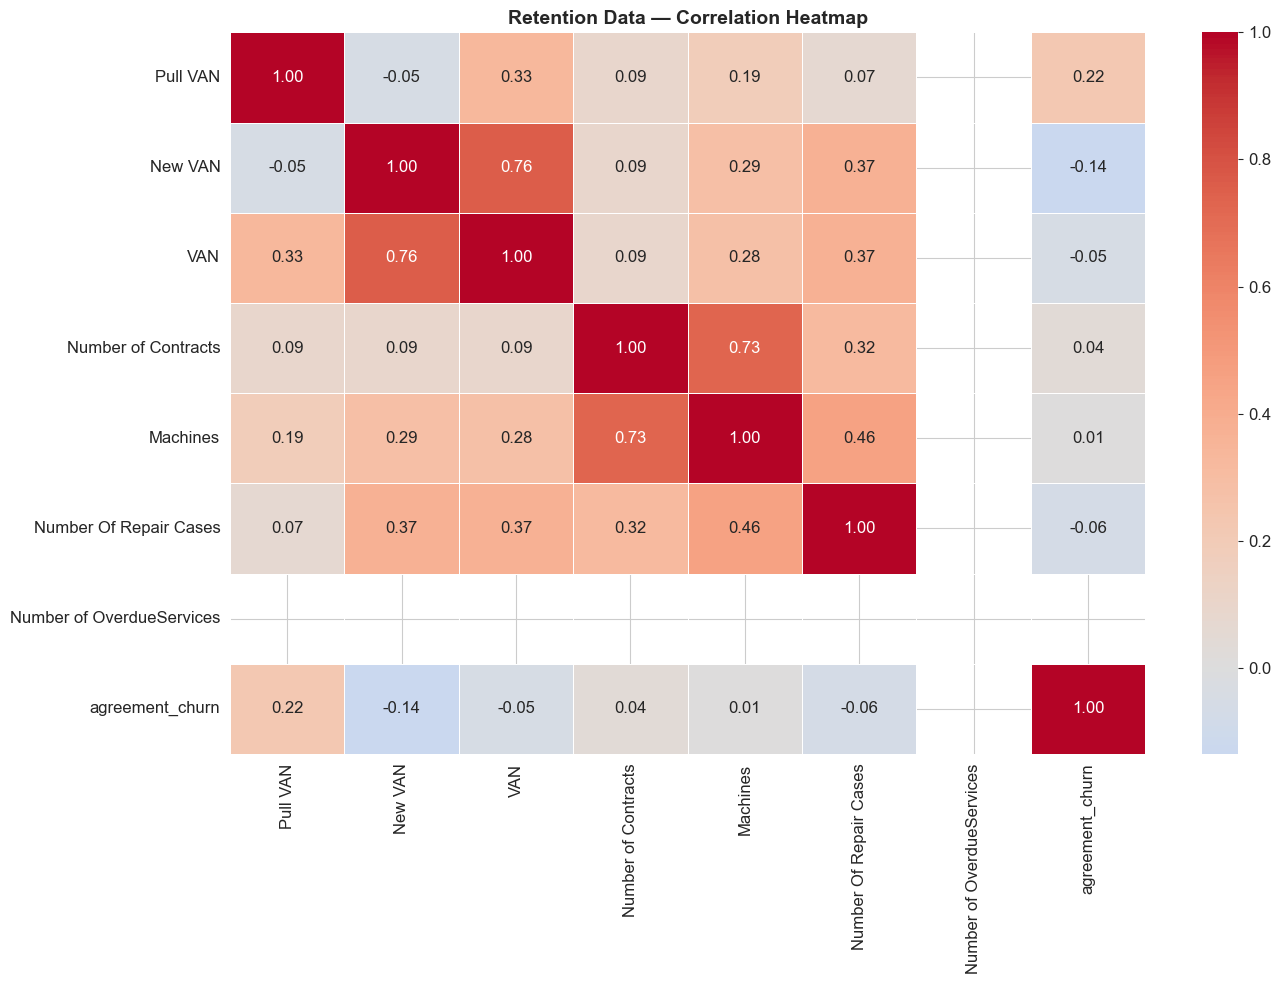

In [27]:
# ── 7a. Retention — correlation of numeric features ──────
ret_numerics = retention.select_dtypes(include=[np.number])

fig, ax = plt.subplots(figsize=(14, 10))
sns.heatmap(ret_numerics.corr(), annot=True, fmt='.2f',
            cmap='coolwarm', center=0, linewidths=0.5, ax=ax)
ax.set_title('Retention Data — Correlation Heatmap',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

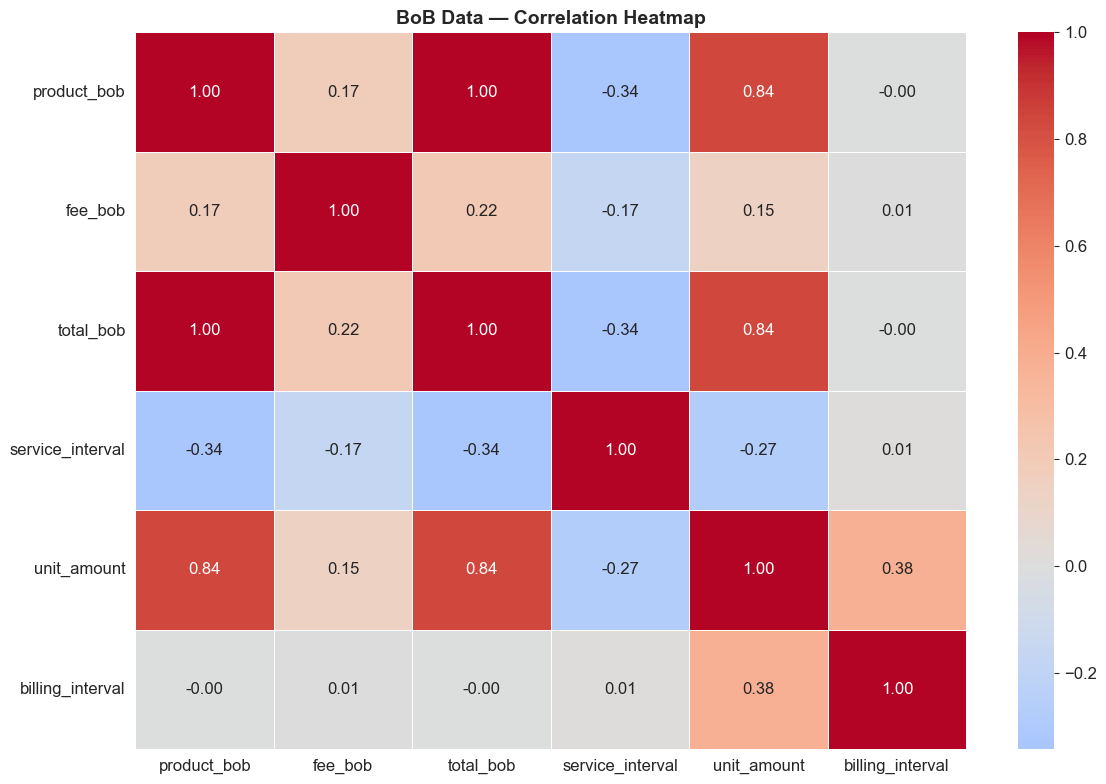

In [28]:
# ── 7b. BoB — correlation of numeric features ────────────
bob_numerics = bob.select_dtypes(include=[np.number])

fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(bob_numerics.corr(), annot=True, fmt='.2f',
            cmap='coolwarm', center=0, linewidths=0.5, ax=ax)
ax.set_title('BoB Data — Correlation Heatmap',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 8. Time-Based Patterns

**WHY:** Churn may follow seasonal trends or be increasing  
over time — this is critical for business planning.

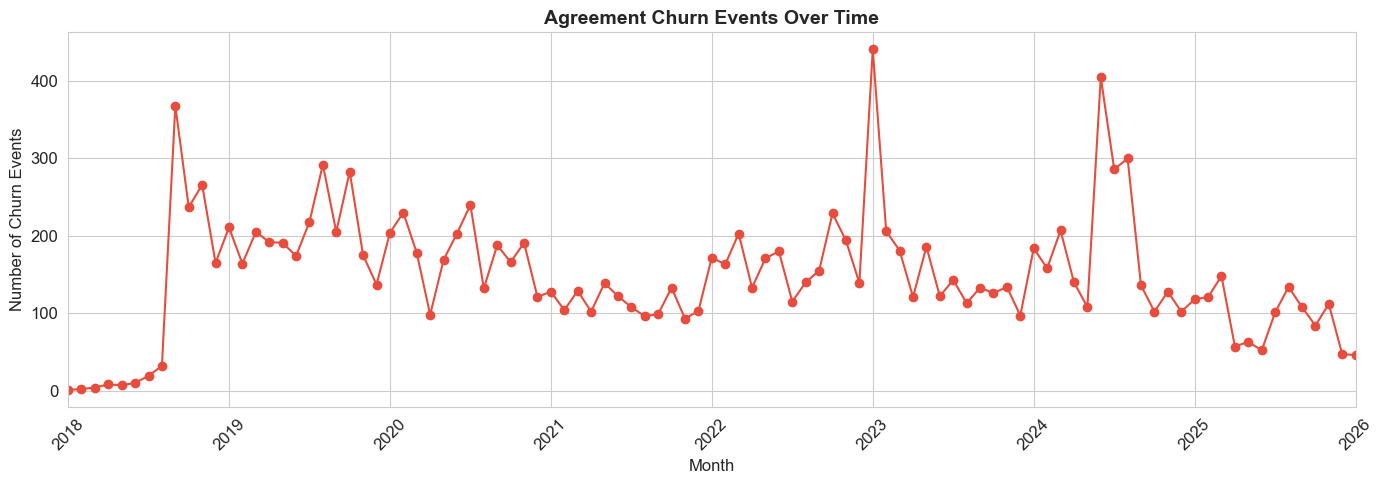

In [29]:
# ── 8a. Parse dates and plot churn over time ─────────────
# WHY: We want to see if churn is spiking in certain months/years.

# Parse Case Creation Date (format: dd-mm-yyyy HH:MM)
retention['case_creation_dt'] = pd.to_datetime(
    retention['Case Creation Date'], dayfirst=True, errors='coerce'
)

# Extract year-month for trend analysis
retention['case_year_month'] = retention['case_creation_dt'].dt.to_period('M')

# Count churn events per month
churn_trend = (
    retention[retention['agreement_churn'] == 1]
    .groupby('case_year_month')
    .size()
)

fig, ax = plt.subplots(figsize=(14, 5))
churn_trend.plot(kind='line', marker='o', color='#e74c3c', ax=ax)
ax.set_title('Agreement Churn Events Over Time',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Number of Churn Events')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

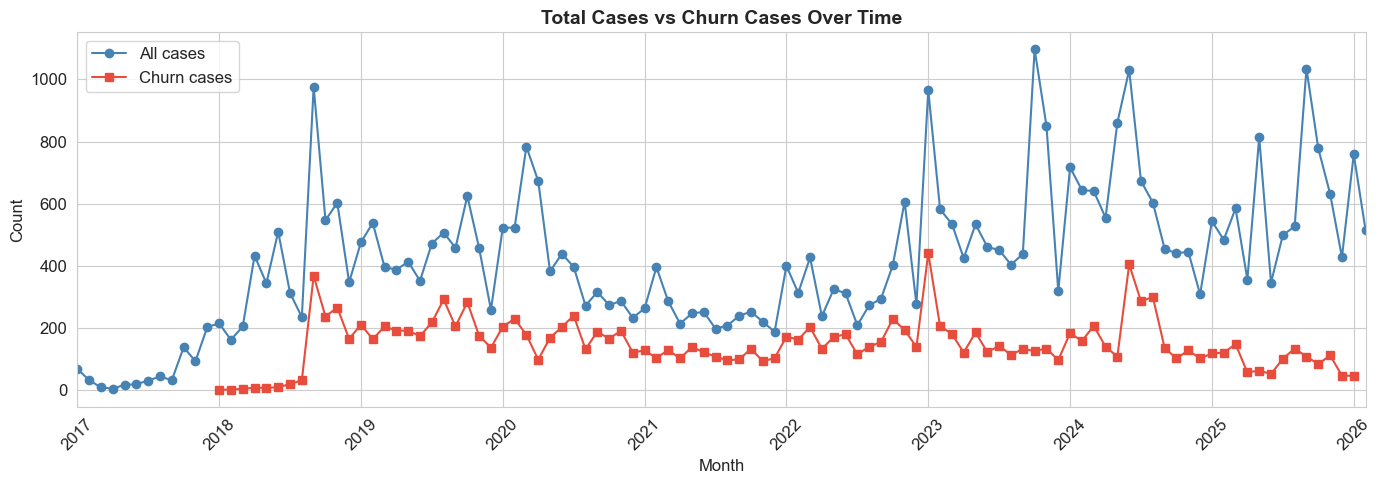

In [30]:
# ── 8b. Total cases vs churn cases over time ─────────────
# WHY: Seeing both lines together shows if churn is growing
# FASTER than the total case volume.

all_trend   = retention.groupby('case_year_month').size()

fig, ax = plt.subplots(figsize=(14, 5))
all_trend.plot(kind='line', marker='o', label='All cases', color='steelblue', ax=ax)
churn_trend.plot(kind='line', marker='s', label='Churn cases', color='#e74c3c', ax=ax)
ax.set_title('Total Cases vs Churn Cases Over Time',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Count')
ax.legend()
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

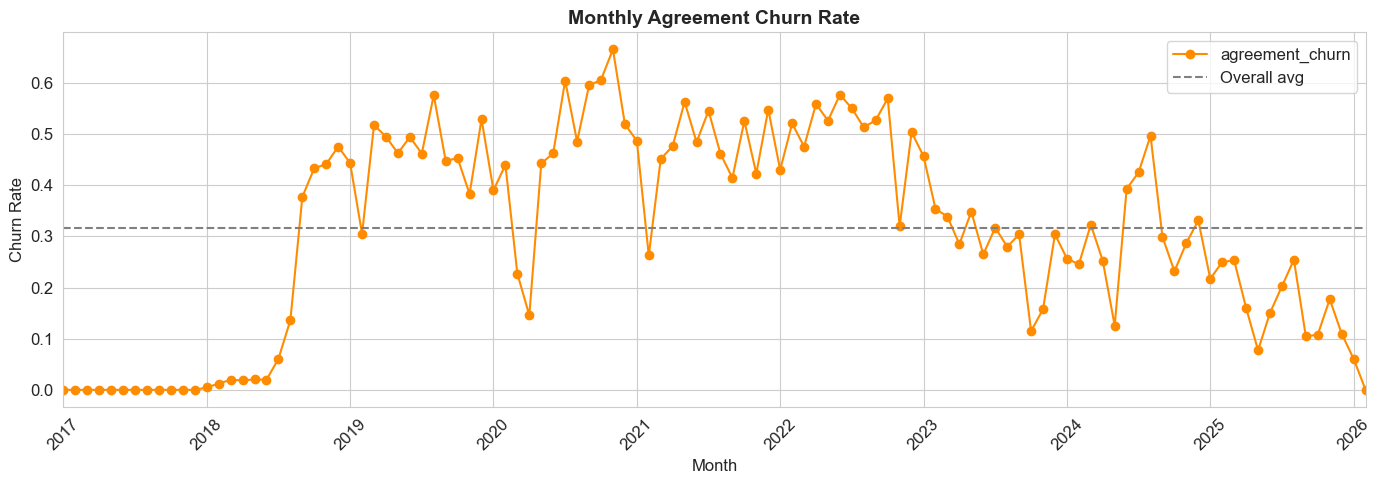

In [31]:
# ── 8c. Monthly churn RATE over time ─────────────────────
# WHY: Raw counts can be misleading if case volume changes.
# The rate tells us the TRUE proportion of churn.

churn_rate_trend = (
    retention.groupby('case_year_month')['agreement_churn'].mean()
)

fig, ax = plt.subplots(figsize=(14, 5))
churn_rate_trend.plot(kind='line', marker='o', color='darkorange', ax=ax)
ax.set_title('Monthly Agreement Churn Rate',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Churn Rate')
ax.axhline(y=retention['agreement_churn'].mean(), color='grey',
           linestyle='--', label='Overall avg')
ax.legend()
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

---
## 9. Key EDA Takeaways

After running the cells above, summarise the main findings here:

1. **Class balance** — note the agreement churn rate and full customer churn rate.  
   If heavily imbalanced, we'll use SMOTE or class-weights during modelling.
2. **Missing values** — identify columns above 50 % missing (candidates for dropping)  
   and columns with moderate missingness (candidates for imputation).
3. **Feature-churn relationships** — which categorical features show the highest  
   variation in churn rate? Which numerical features separate churned from non-churned?
4. **Correlations** — watch out for highly correlated pairs (e.g. `Number of Contracts`  
   vs `Machines`).
5. **Time trends** — is churn increasing, stable, or seasonal?

In [32]:
# ── Cleanup temp columns before saving ───────────────────
# Drop helper columns we created just for EDA
retention.drop(columns=['agreement_churn', 'case_creation_dt',
                        'case_year_month'], inplace=True, errors='ignore')